# UNet

## Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# SETUP PATH
# ============================================================

WORK_DIR = Path("/content/drive/MyDrive/Computational Imaging/Code")
RETINA_DATASET_PATH = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images")

# Cartella dove salveremo il dataset preprocessato in .pt
PROCESSED_DATASET_DIR = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retina_processed")

# Find IPPy folder
for base in (WORK_DIR, *WORK_DIR.parents):
    if (base / "IPPy").exists():
        sys.path.append(str(base))
        break
else:
    raise FileNotFoundError("Could not find IPPy folder.")

from IPPy import operators, utilities

device = utilities.get_device()
torch.manual_seed(0)

print("Device:", device)
print("Working directory:", WORK_DIR)
print("Retina dataset path:", RETINA_DATASET_PATH)
print("Processed dataset path:", PROCESSED_DATASET_DIR)

Device: cuda
Working directory: /content/drive/MyDrive/Computational Imaging/Code
Retina dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images
Processed dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed


## Dataset

In [6]:
class RetinaPTDataset(Dataset):
    def __init__(self, pt_path):
        super().__init__()

        payload = torch.load(pt_path, map_location="cpu")

        self.clean = payload["clean"]
        self.degraded = payload["degraded"]
        self.source_paths = payload["source_paths"]
        self.metadata = payload["metadata"]

    def __len__(self):
        return self.clean.shape[0]

    def __getitem__(self, idx):
        y = self.degraded[idx]   # input degradato
        x = self.clean[idx]      # target pulito
        return y, x
    
def noise_file_name(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}.pt"

## Dataloader

In [7]:
noise_level = 0.01 # Change for different noise level
batch_size = 8

train_pt = PROCESSED_DATASET_DIR / "train" / noise_file_name(noise_level)
val_pt = PROCESSED_DATASET_DIR / "validation" / noise_file_name(noise_level)
test_pt = PROCESSED_DATASET_DIR / "test" / noise_file_name(noise_level)

train_dataset_pt = RetinaPTDataset(train_pt)
val_dataset_pt = RetinaPTDataset(val_pt)
test_dataset_pt = RetinaPTDataset(test_pt)

train_loader = DataLoader(
    train_dataset_pt,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset_pt,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset_pt,
    batch_size=batch_size,
    shuffle=False,
)

print("Noise level:", noise_level)
print("Train samples:", len(train_dataset_pt))
print("Validation samples:", len(val_dataset_pt))
print("Test samples:", len(test_dataset_pt))
print("Metadata:", train_dataset_pt.metadata)

Noise level: 0.01
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.01, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


## UNet

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(channels, feature))
            channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2,
                )
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(
                    x,
                    size=skip_connection.shape[2:],
                    mode="bilinear",
                    align_corners=False,
                )

            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](x)

        x = self.final_conv(x)

        # Output image range [0,1]
        x = torch.sigmoid(x)

        return x

In [9]:
model = UNet(
    in_channels=1,
    out_channels=1,
    features=(32, 64, 128, 256),
).to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

print("Number of parameters:", sum(p.numel() for p in model.parameters()))

Number of parameters: 7759521


## Train & Validation

In [10]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for y, x in tqdm(dataloader, desc="Training", leave=False):
        y = y.to(device)
        x = x.to(device)

        optimizer.zero_grad()

        x_hat = model(y)
        loss = loss_fn(x_hat, x)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)

    return total_loss / len(dataloader.dataset)


def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for y, x in tqdm(dataloader, desc="Validation", leave=False):
            y = y.to(device)
            x = x.to(device)

            x_hat = model(y)
            loss = loss_fn(x_hat, x)

            total_loss += loss.item() * y.size(0)

    return total_loss / len(dataloader.dataset)

## Training

In [15]:
num_epochs = 50

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = WORK_DIR / f"unet_noise_{str(noise_level).replace('.', '_')}.pt"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
    )

    val_loss = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=device,
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "noise_level": noise_level,
                "val_loss": best_val_loss,
            },
            best_model_path,
        )
        print("Saved best model:", best_model_path)

Training:   0%|          | 0/350 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch [1/50] Train Loss: 0.000118 | Val Loss: 0.000129
Saved best model: /content/drive/MyDrive/Computational Imaging/Code/unet_noise_0_01.pt


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch [49/50] Train Loss: 0.000041 | Val Loss: 0.000043
Saved best model: /content/drive/MyDrive/Computational Imaging/Code/unet_noise_0_01.pt


Training:   0%|          | 0/350 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch [50/50] Train Loss: 0.000040 | Val Loss: 0.000043
Saved best model: /content/drive/MyDrive/Computational Imaging/Code/unet_noise_0_01.pt


## Results

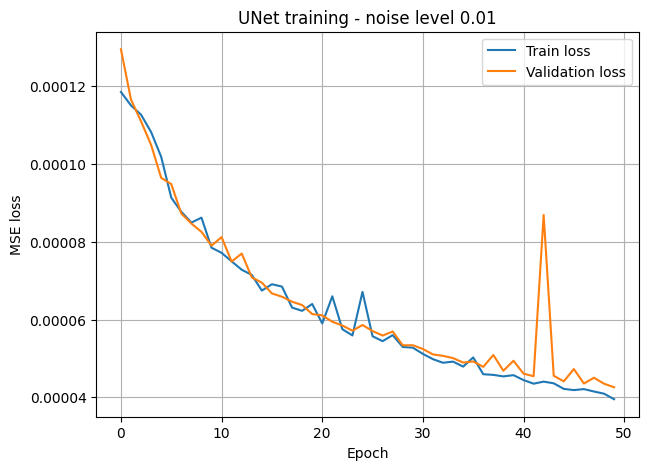

In [16]:
# ============================================================
# PLOT LOSSES
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title(f"UNet training - noise level {noise_level}")
plt.legend()
plt.grid(True)
plt.show()

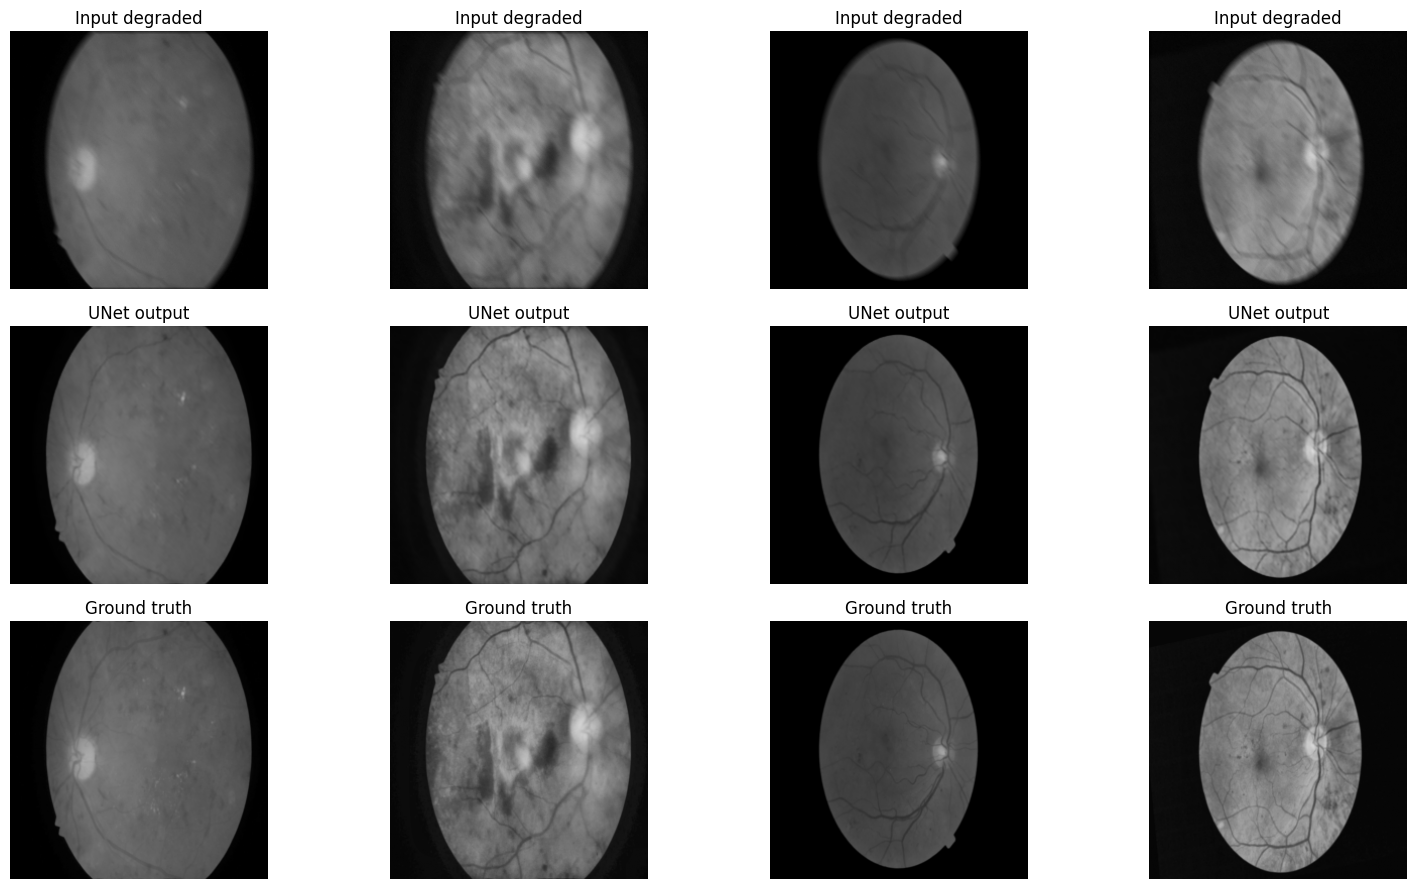

In [17]:
# ============================================================
# VISUALIZE UNET RECONSTRUCTIONS
# ============================================================

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

y_batch, x_batch = next(iter(test_loader))

y_batch = y_batch.to(device)
x_batch = x_batch.to(device)

with torch.no_grad():
    x_hat = model(y_batch)

y_batch = y_batch.cpu()
x_batch = x_batch.cpu()
x_hat = x_hat.cpu().clamp(0, 1)

n = 4

fig, axes = plt.subplots(3, n, figsize=(4 * n, 9))

for i in range(n):
    axes[0, i].imshow(y_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Input degraded")
    axes[0, i].axis("off")

    axes[1, i].imshow(x_hat[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("UNet output")
    axes[1, i].axis("off")

    axes[2, i].imshow(x_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[2, i].set_title("Ground truth")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# PSNR METRIC
# ============================================================

def compute_psnr(x_hat, x, max_val=1.0):
    mse = torch.mean((x_hat - x) ** 2, dim=(1, 2, 3))
    psnr = 10 * torch.log10(max_val ** 2 / mse)
    return psnr


# ============================================================
# EVALUATE PSNR ON TEST SET
# ============================================================

model.eval()

psnr_degraded_list = []
psnr_unet_list = []

with torch.no_grad():
    for y, x in tqdm(test_loader, desc="Testing"):
        y = y.to(device)
        x = x.to(device)

        x_hat = model(y).clamp(0, 1)

        psnr_degraded = compute_psnr(y, x)
        psnr_unet = compute_psnr(x_hat, x)

        psnr_degraded_list.append(psnr_degraded.cpu())
        psnr_unet_list.append(psnr_unet.cpu())

psnr_degraded_all = torch.cat(psnr_degraded_list)
psnr_unet_all = torch.cat(psnr_unet_list)

print("Average PSNR degraded input:", psnr_degraded_all.mean().item())
print("Average PSNR UNet output:", psnr_unet_all.mean().item())

Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Average PSNR degraded input: 33.3523063659668
Average PSNR UNet output: 45.32774353027344
